# SUPPORT VECTOR MACHINE

--- Task 1: Exploratory Data Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None

Summary Statistics:
        Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567  

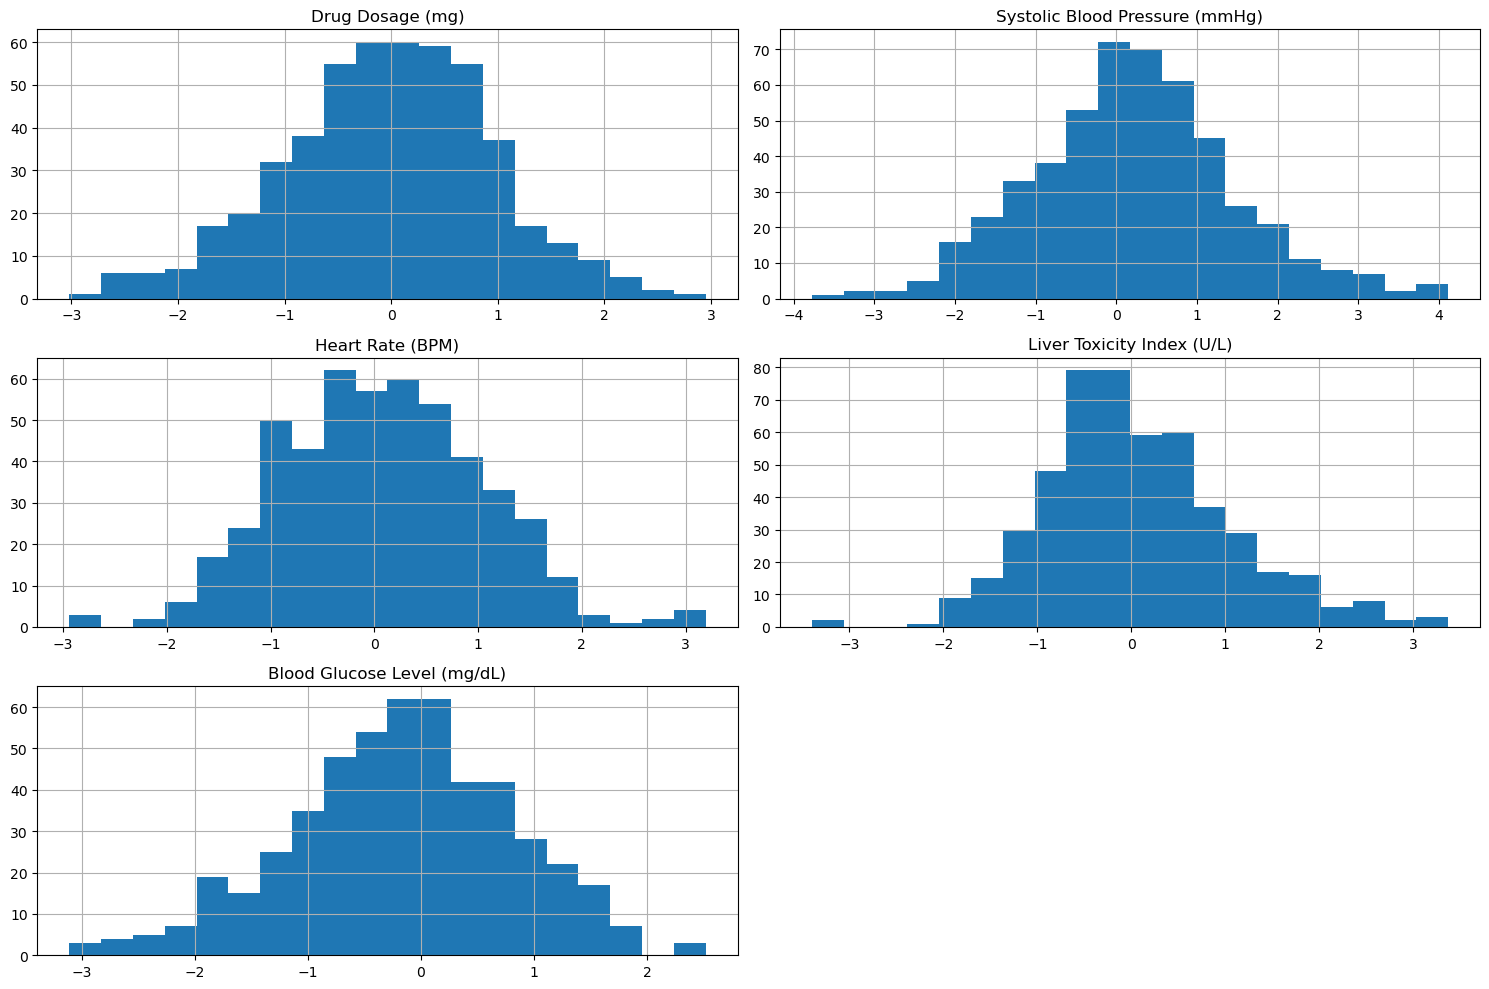

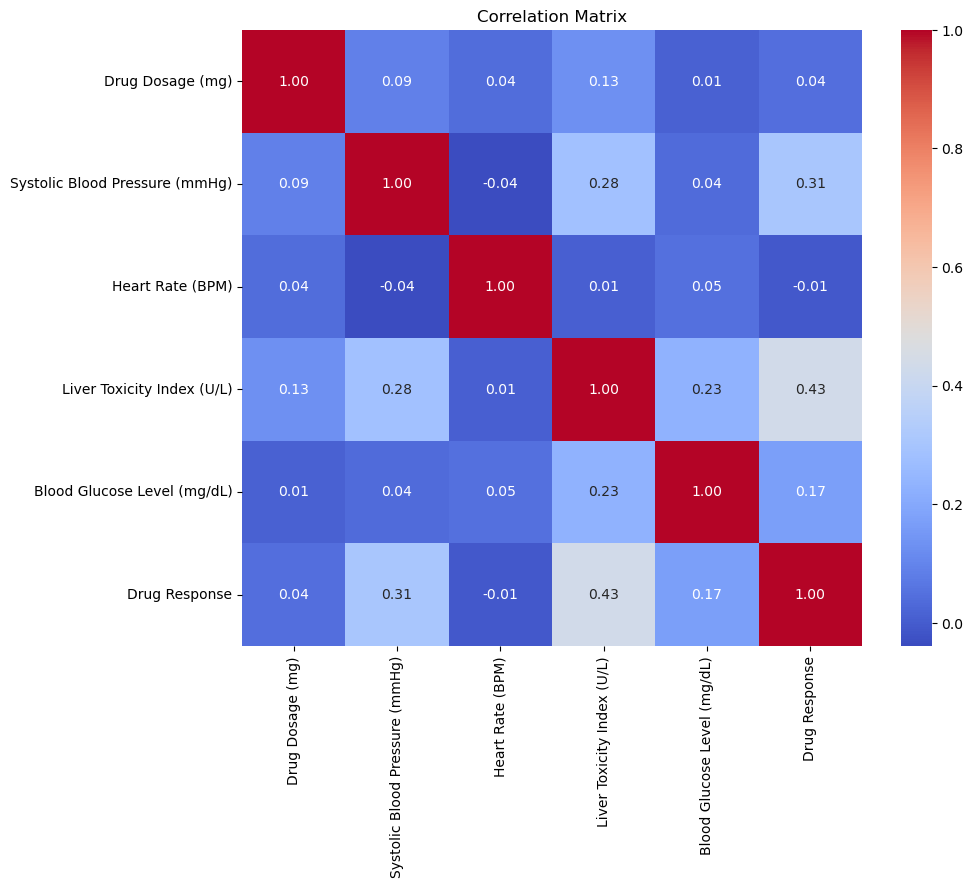

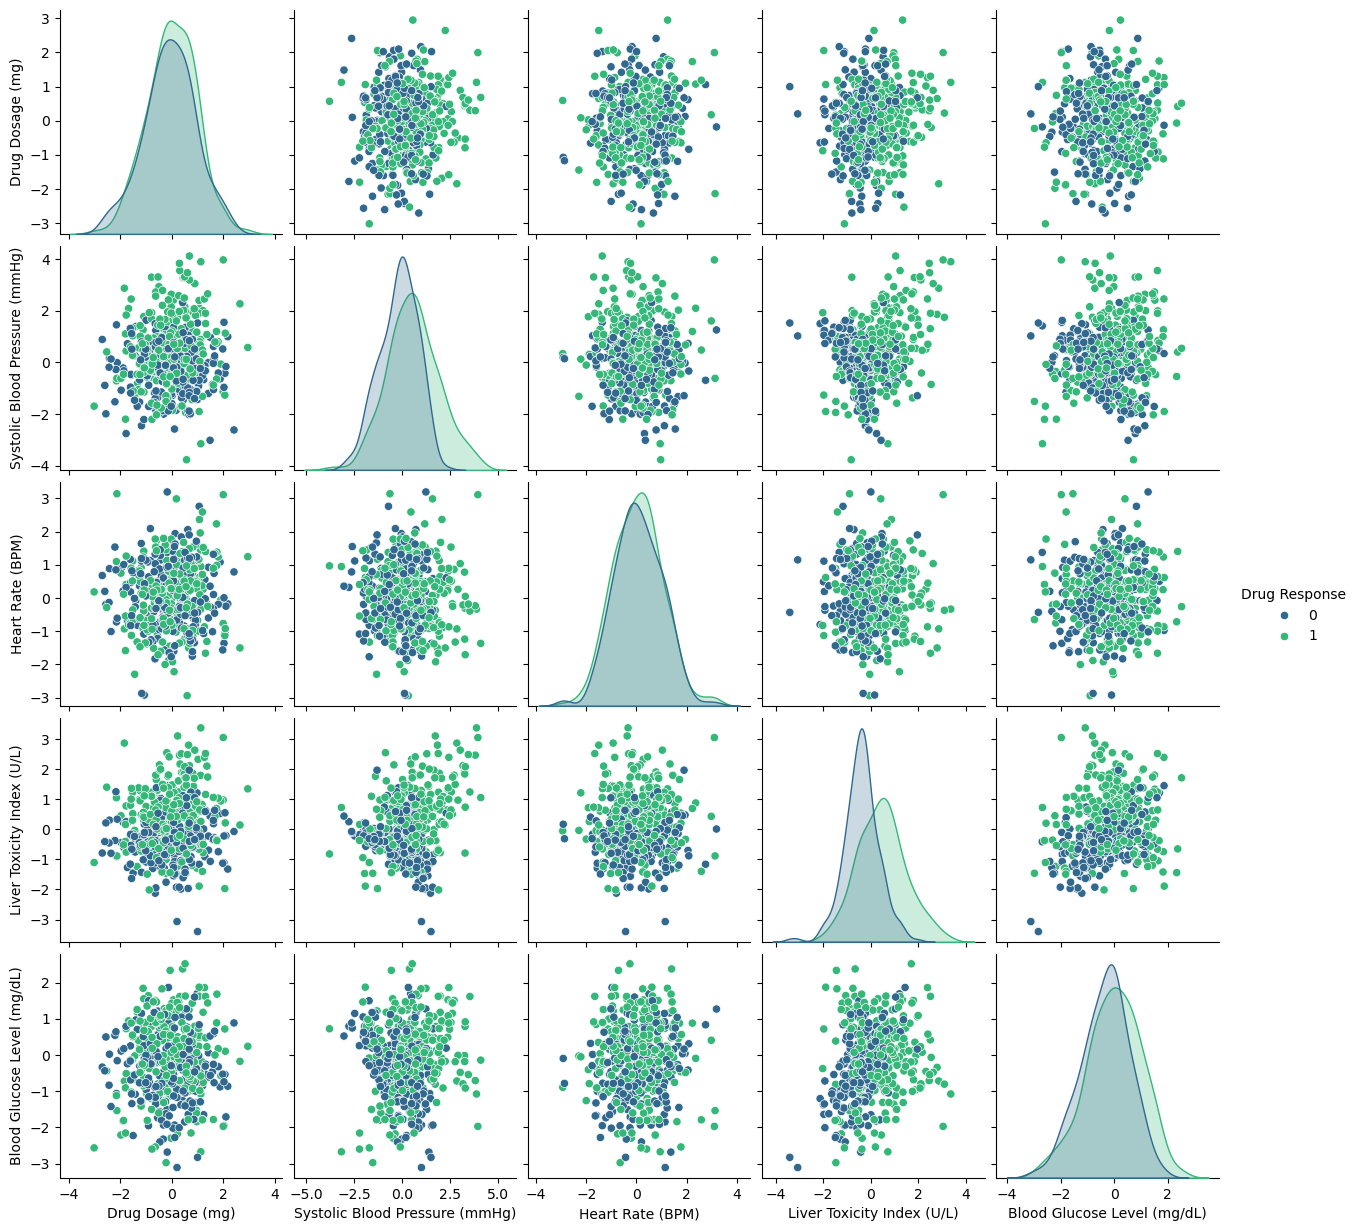

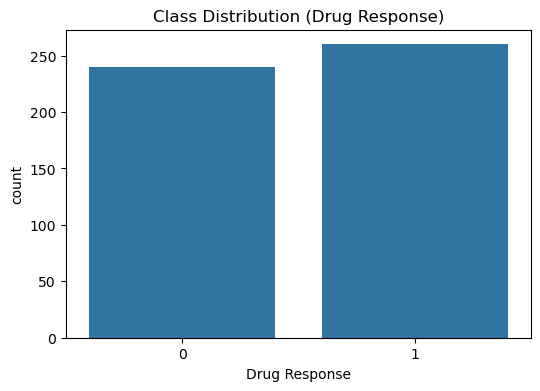

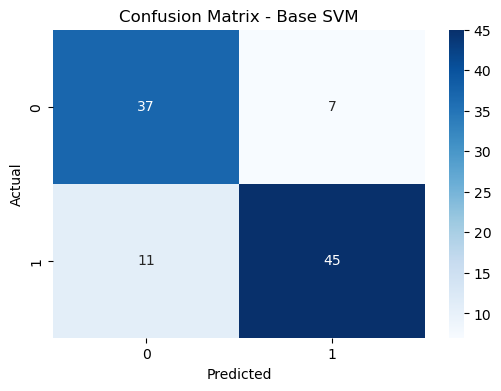

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('Pharma_Industry.csv')

# Task 1: EDA
print("--- Task 1: Exploratory Data Analysis ---")
print(df.info())
print("\nSummary Statistics:\n", df.describe())

# Histograms
df.drop('Drug Response', axis=1).hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.savefig('histograms.png')

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')

# Task 2: Data Preprocessing
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 3: Data Visualization
# Pairplot
sns.pairplot(df, hue='Drug Response', palette='viridis')
plt.savefig('pairplot.png')

# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Drug Response', data=df)
plt.title('Class Distribution (Drug Response)')
plt.savefig('class_distribution.png')

# Task 4: SVM Implementation
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_train, y_train)
y_pred = svm_base.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}
print("\n--- Task 4: Base SVM (RBF) Performance ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# Task 5: Visualization of results
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Base SVM')
plt.savefig('confusion_matrix.png')

# Task 6: Parameter Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_train, y_train)
print("\n--- Task 6: Best Parameters ---")
print(grid.best_params_)

# Task 7: Comparison of Kernels
results = []
for k in ['linear', 'poly', 'rbf']:
    m = SVC(kernel=k)
    m.fit(X_train, y_train)
    y_p = m.predict(X_test)
    results.append({'Kernel': k, 'Accuracy': accuracy_score(y_test, y_p)})

print("\n--- Task 7: Kernel Comparison ---")
comparison_df = pd.DataFrame(results)
print(comparison_df)